## Project's title : Hybrid Time Series Forecasting for Retail: Statistical, ML, and Deep Learning Models for Weekly Sales Prediction and Deployment.


## INTRODUCTION
Retail demand forecasting is essential for inventory optimization and strategic planning. This study develops a weekly sales forecasting framework using the Walmart dataset (2010–2012). The proposed pipeline integrates statistical time-series models, machine learning algorithms, and deep learning architectures. The objective is to evaluate whether hybrid modeling approaches improve predictive accuracy compared to classical baselines while maintaining computational efficiency suitable for production deployment.

## I.SUMMARY
This project develops a comprehensive weekly retail sales forecasting framework integrating statistical, machine learning, and deep learning approaches. The objective is to evaluate predictive performance across modeling paradigms while ensuring methodological rigor and deployment feasibility.
The workflow consists of:
1.	Data quality assessment and preprocessing
Validation of data integrity, missing values, duplicates, and temporal consistency.
2.	Stationarity and seasonality diagnostics
Statistical tests and visual analysis to determine temporal structure and modeling requirements.
3.	Feature engineering
Creation of lag features, rolling statistics, calendar variables, and optional exogenous indicators.
4.	Model comparison
Performance evaluation across multiple forecasting approaches:

-	Seasonal naive baseline
-	Linear Regression
- Random Forest
-	SARIMA
- LSTM / GRU neural networks
5.	Residual diagnostics and overfitting analysis
Evaluation of model assumptions and generalization behavior.
6.	Synthetic data augmentation (experimental component)
Controlled generation of additional samples for robustness testing, with statistical validation.
7.	Model serialization and deployment preparation
Packaging of the selected model for reproducible execution and inference.
Deep learning models are trained on structured sequential tensors derived from engineered time-series features. Synthetic data is introduced only as an experimental extension and is evaluated critically to verify that it preserves statistical properties of the original dataset.
The system is designed with reproducibility and production constraints in mind, including containerized execution and API-based inference architecture.

The system is designed for containerized deployment using Docker and cloud infrastructure (AWS / Vercel), exposing forecasts via API endpoints.

## II.PROBLEM STATEMENT AND OBJECTIVES
a. Problem Statement
Weekly retail sales exhibit several characteristics that complicate forecasting:

•	Presence of trend components

•	Potential seasonal structure

•	Non-stationarity

•	Heterogeneity across stores

•	Influence of external economic factors

These properties create challenges for predictive modeling. Traditional statistical models rely on assumptions such as stationarity and linearity, which may limit their ability to capture complex nonlinear relationships. Machine learning models can model nonlinear patterns but depend strongly on feature engineering. Deep learning architectures such as LSTM or GRU are capable of modeling long-term temporal dependencies, but they typically require larger datasets and are prone to overfitting when data is limited.
In addition to predictive performance, real-world forecasting systems must satisfy practical constraints including computational efficiency, reproducibility, and deployability.

Research Question :
Can a hybrid modeling framework combining statistical, machine learning, and deep learning approaches improve weekly retail demand forecasting accuracy compared to baseline methods while remaining suitable for production deployment?




## b.General Objective
To design, evaluate, and deploy a weekly retail sales forecasting system that integrates statistical, machine learning, and deep learning models within a reproducible pipeline, while assessing predictive performance, robustness, and scalability.


# c. Specific Objectives
Data Diagnostics
•	Assess dataset completeness and consistency
•	Detect duplicates and anomalies
•	Validate chronological ordering
•	Evaluate stationarity and seasonal structure

2. Feature Engineering
•	Generate lag features (1–52 weeks)
•	Compute rolling statistics (mean, volatility)
•	Extract calendar-based variables
•	Incorporate exogenous indicators when relevant

3. Statistical Modeling
•	Implement SARIMA-type models
•	Select parameters using diagnostic plots and tests
•	Apply strict temporal validation
•	Evaluate performance using RMSE and MAE

4. Machine Learning Modeling
•	Train regression-based models (Linear Regression, Random Forest)
•	Measure generalization gap
•	Analyze feature importance
•	Evaluate dimensionality reduction strategies if beneficial

5. Deep Learning Modeling
•	Construct sequential datasets
•	Train LSTM and CNN
•	Apply strict temporal splits
•	Monitor training vs validation error
•	Mitigate overfitting via regularization techniques

6. Synthetic Data Evaluation (Experimental)
•	Generate synthetic samples using controlled stochastic perturbations
•	Verify distribution similarity with real data
•	Compare predictive performance with and without augmentation
•	Assess whether synthetic data improves robustness without distorting temporal structure

7. Model Comparison
•	Benchmark all models against naive and seasonal baselines
•	Analyze residual distributions
•	Evaluate stability across time segments
•	Identify best trade-off between accuracy and complexity

8. Deployment Preparation
•	Serialize selected model
•	Package execution environment
•	Design API inference interface
•	Prepare cloud deployment configuration
•	Define monitoring metrics and performance thresholds




# Setup 

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.feature_selection import mutual_info_regression
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_squared_error, mean_absolute_error
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.stats.diagnostic import acorr_ljungbox
from pmdarima import auto_arima
import joblib
import warnings
warnings.filterwarnings('ignore')

print("All imports successful!")

All imports successful!


#Data Pipeline: Data Preparation for Weekly Sales Forecasting

This notebook covers the steps of loading, cleaning, transforming, and preparing the Walmart dataset (2010–2012) for model training.

# Stage 1 — Load & Explore Your Data
The very first step is understanding what we have. We load the Walmart dataset and run all five inspection tools before forming any opinion about the data.

#Data Loading

# Step 1.1  Load the data 
We begin by loading the dataset.
Purpose :
Load the CSV file using pandas.

Check the first 5 rows to confirm columns (Store, Date, Weekly_Sales, etc.) are correctly read.

Display the number of rows, columns, and memory usage to assess dataset size.


In [2]:
# Relative path from the notebook in the code/ folder to data/raw/
DATA_PATH = Path("..") / "data" / "raw" / "Walmart.csv"

# Read the CSV file
df = pd.read_csv(DATA_PATH, encoding="utf-8", engine="python")
print(f'Rows:    {df.shape[0]}')
print(f'Columns: {df.shape[1]}')


Rows:    6435
Columns: 8


In [3]:
# Relative path from the notebook in the code/ folder to data/raw/
DATA_PATH = Path("..") / "data" / "raw" / "Walmart.csv"

# Read the CSV file
df = pd.read_csv(DATA_PATH, encoding="utf-8", engine="python")

# Display the first few rows
df.head()

,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI(customer price index),Unemployment
0,1,5/2/2010,1643690.90,0,42.31,2.572,211.096358,8.106
1,1,12/2/2010,1641957.44,1,38.51,2.548,211.242170,8.106
2,1,19-02-2010,1611968.17,0,39.93,2.514,211.289143,8.106
3,1,26-02-2010,1409727.59,0,46.63,2.561,211.319643,8.106
4,1,5/3/2010,1554806.68,0,46.50,2.625,211.350143,8.106


- Dataset contains 6,435 rows and 8 columns.

- No missing values (df.isna().sum() returns 0 for all columns).

- Memory usage is 0.70 MB, which is manageable.

# Dataset Overview

We check dataset dimensions and memory usage to understand its scale and whether optimization might be needed.

In [4]:
print("Rows:", len(df))
print("Columns:", len(df.columns))
print("Memory usage (MB):", df.memory_usage(deep=True).sum() / 1024**2)

Rows: 6435
Columns: 8
Memory usage (MB): 0.7512693405151367


# Dataset overview:
- The dataset contains 6,435 rows and 8 columns, indicating a moderate-sized dataset.
- Memory usage is low (approx 0.7 MB), so no memory optimization is required.

# Step 1.2  Inspect data types
Column Types

Understanding column data types is essential before performing transformations.
In particular, we verify numeric variables and date fields.

In [5]:
df.dtypes

Store                          int64
Date                          object
Weekly_Sales                 float64
Holiday_Flag                   int64
Temperature                  float64
Fuel_Price                   float64
CPI(customer price index)    float64
Unemployment                 float64
dtype: object

# Dataset column types summary:
-  Store: store ID (categorical encoded as integer)
-  Date : date variable (to convert to datetime)
- Weekly_Sales : target variable (continuous)
- Holiday_Flag : binary indicator (holiday or not)
- Temperature, Fuel_Price, CPI, Unemployment : numerical economic features

# Step 1.3  Preview the first 10 rows 
Preview the first 10 rows

In [6]:
df.head(10)

,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI(customer price index),Unemployment
0,1,5/2/2010,1643690.90,0,42.31,2.572,211.096358,8.106
1,1,12/2/2010,1641957.44,1,38.51,2.548,211.242170,8.106
2,1,19-02-2010,1611968.17,0,39.93,2.514,211.289143,8.106
3,1,26-02-2010,1409727.59,0,46.63,2.561,211.319643,8.106
4,1,5/3/2010,1554806.68,0,46.50,2.625,211.350143,8.106
5,1,12/3/2010,1439541.59,0,57.79,2.667,211.380643,8.106
6,1,19-03-2010,1472515.79,0,54.58,2.720,211.215635,8.106
7,1,26-03-2010,1404429.92,0,51.45,2.732,211.018042,8.106
8,1,2/4/2010,1594968.28,0,62.27,2.719,210.820450,7.808
9,1,9/4/2010,1545418.53,0,65.86,2.770,210.622857,7.808


# Step 1.4  Summary statistics
The prediction target is Weekly_Sales. We inspect descriptive statistics to understand distribution, scale, and variability.

In [7]:
df.describe()

,Store,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI(customer price index),Unemployment
count,6435.000000,6.435000e+03,6435.000000,6435.000000,6435.000000,6435.000000,6435.000000
mean,23.000000,1.046965e+06,0.069930,60.663782,3.358607,171.578394,7.999151
std,12.988182,5.643666e+05,0.255049,18.444933,0.459020,39.356712,1.875885
min,1.000000,2.099862e+05,0.000000,-2.060000,2.472000,126.064000,3.879000
25%,12.000000,5.533501e+05,0.000000,47.460000,2.933000,131.735000,6.891000
50%,23.000000,9.607460e+05,0.000000,62.670000,3.445000,182.616521,7.874000
75%,34.000000,1.420159e+06,0.000000,74.940000,3.735000,212.743293,8.622000
max,45.000000,3.818686e+06,1.000000,100.140000,4.468000,227.232807,14.313000


# Step 1.5  Full info (non-null counts, memory)

In [8]:
df.info() # displays column types, non-null counts, and memory usage all at once

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6435 entries, 0 to 6434
Data columns (total 8 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Store                      6435 non-null   int64  
 1   Date                       6435 non-null   object 
 2   Weekly_Sales               6435 non-null   float64
 3   Holiday_Flag               6435 non-null   int64  
 4   Temperature                6435 non-null   float64
 5   Fuel_Price                 6435 non-null   float64
 6   CPI(customer price index)  6435 non-null   float64
 7   Unemployment               6435 non-null   float64
dtypes: float64(5), int64(2), object(1)
memory usage: 402.3+ KB


# Challenge
df.describe(include="all") adds statistics for all columns including non-numerical ones like Date.

In [9]:
df.describe(include="all")

,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI(customer price index),Unemployment
count,6435.000000,6435,6.435000e+03,6435.000000,6435.000000,6435.000000,6435.000000,6435.000000
unique,NaN,143,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,5/2/2010,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,45,NaN,NaN,NaN,NaN,NaN,NaN
mean,23.000000,NaN,1.046965e+06,0.069930,60.663782,3.358607,171.578394,7.999151
std,12.988182,NaN,5.643666e+05,0.255049,18.444933,0.459020,39.356712,1.875885
min,1.000000,NaN,2.099862e+05,0.000000,-2.060000,2.472000,126.064000,3.879000
25%,12.000000,NaN,5.533501e+05,0.000000,47.460000,2.933000,131.735000,6.891000
50%,23.000000,NaN,9.607460e+05,0.000000,62.670000,3.445000,182.616521,7.874000
75%,34.000000,NaN,1.420159e+06,0.000000,74.940000,3.735000,212.743293,8.622000


# df.sample(10) returns 10 randomly selected rows from the dataset, while df.head() always returns the first 10 rows.

We prefer df.sample(10) when we want a representative view of the full dataset, not just the beginning. For exemple, if the data is sorted by Store, df.head() would only show Store 1, while df.sample() would show rows from different stores and different time periods.

In [10]:
df.sample(10)

,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI(customer price index),Unemployment
4589,33,7/5/2010,326870.13,0,75.40,3.127,126.289800,9.849
1547,11,4/5/2012,1370251.22,0,79.07,3.749,225.179751,6.664
6300,45,2/4/2010,877235.96,0,47.74,2.850,181.865754,8.899
1551,11,1/6/2012,1361595.33,0,81.67,3.501,225.251831,6.664
2527,18,9/12/2011,1368471.23,0,42.36,3.470,136.503067,8.471
3828,27,16-03-2012,1635984.07,0,49.60,4.021,141.554780,8.009
1715,12,26-10-2012,974697.60,0,65.95,4.301,131.193097,10.199
4354,31,29-04-2011,1331137.96,0,70.19,3.810,215.277268,7.931
4020,29,28-05-2010,577627.66,0,65.64,2.906,132.293936,10.160
3007,22,5/3/2010,1009201.24,0,36.82,2.766,135.573260,8.283


# Step 2.1 — Missing Values (Completeness)
Let's check if are there any missing values in the dataset

In [11]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)

quality_report = pd.DataFrame({
    "missing_count": missing,
    "missing_pct":   missing_pct,
})

print(quality_report[quality_report["missing_count"] > 0])

Empty DataFrame
Columns: [missing_count, missing_pct]
Index: []


# Step 2.2 — Duplicate Rows (Uniqueness)
Let's check if are there any duplicate rows or duplicate Store+Date combinations

In [12]:
n_duplicates = df.duplicated().sum()
print("Duplicate rows:", n_duplicates)

if n_duplicates > 0:
    print(df[df.duplicated(keep=False)].head(6))

# Store + Date duplicates
duplicates_count = df.reset_index().duplicated(subset=["Store", "Date"]).sum()
print("Store+Date duplicates:", duplicates_count)

Duplicate rows: 0
Store+Date duplicates: 0


# Step 2.3 — Value Distributions (Consistency)
Check that categorical columns contain valid and uniform values.

In [13]:
df["Holiday_Flag"].value_counts()

Holiday_Flag
0    5985
1     450
Name: count, dtype: int64

# Step 2.4 — Range Check (Accuracy & Validity)
Check that numerical values are plausible and within expected ranges.

Weekly_Sales — min: 209986.25 , max: 3818686.45 , mean: 1046964.88
Outliers detected: 34


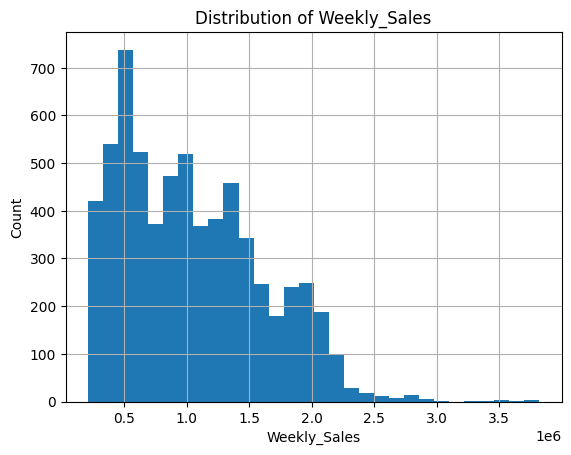

In [14]:
col = "Weekly_Sales"
print(col, "— min:", df[col].min(), ", max:", df[col].max(), ", mean:", round(df[col].mean(), 2))

# IQR outlier detection
Q1 = df["Weekly_Sales"].quantile(0.25)
Q3 = df["Weekly_Sales"].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = df[(df["Weekly_Sales"] < lower) | (df["Weekly_Sales"] > upper)]
print("Outliers detected:", len(outliers))

df[col].hist(bins=30)
plt.title("Distribution of " + col)
plt.xlabel(col)
plt.ylabel("Count")
plt.show()

# Step 2.5 — Date Format (Consistency)
Check that the Date column has a uniform format.

In [15]:
print(df["Date"].head(10))
print(df["Date"].dtype)

0      5/2/2010
1     12/2/2010
2    19-02-2010
3    26-02-2010
4      5/3/2010
5     12/3/2010
6    19-03-2010
7    26-03-2010
8      2/4/2010
9      9/4/2010
Name: Date, dtype: object
object


# Challenge
Create a correlation heatmap to spot relationships between numerical columns


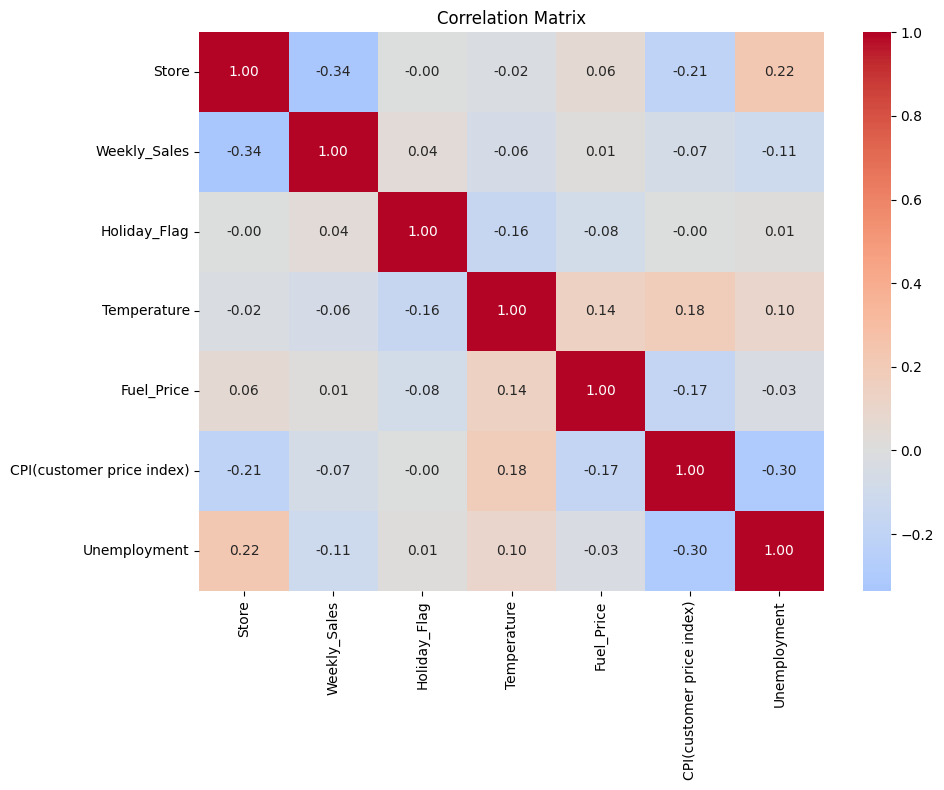

In [16]:
plt.figure(figsize=(10, 8))
sns.heatmap(df.select_dtypes(include="number").corr(),
            annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()


# Target Variable Analysis

The prediction target is Weekly_Sales.
We inspect descriptive statistics to understand distribution, scale, and variability.

In [17]:
df["Weekly_Sales"].describe()

count    6.435000e+03
mean     1.046965e+06
std      5.643666e+05
min      2.099862e+05
25%      5.533501e+05
50%      9.607460e+05
75%      1.420159e+06
max      3.818686e+06
Name: Weekly_Sales, dtype: float64

# Comments:
- Weekly sales average approximative 1.05M with high variability (std approximative 564k).
- The distribution is right-skewed: most values lie below approximative 1.42M,
- but some extreme weeks reach up to approximative 3.8M, indicating outliers.

# Date Parsing

# Purpose
Handle mixed date formats (DD/MM/YYYY and MM/DD/YYYY).

#Approach

Convert the Date column to string and standardize separators (/).

First pass: Parse with dayfirst=True (DD/MM/YYYY format).

Second pass: Fix remaining NaN values with dayfirst=False (MM/DD/YYYY format).

Verify no unparsed dates remain.


In [18]:
# 2. Robust date parsing
# Convert to string and standardize separators
s = df['Date'].astype(str).str.replace('-', '/', regex=False)

# First pass: try dayfirst=True
dt = pd.to_datetime(s, dayfirst=True, errors='coerce')

# Second pass: fix remaining NaNs with dayfirst=False
bad = dt.isna()
dt.loc[bad] = pd.to_datetime(s[bad], dayfirst=False, errors='coerce')

# Assign final parsed dates
df['Date'] = dt

# Ensure no unparsed dates remain
if df['Date'].isna().any():
    raise ValueError("Unparsed dates remain!")

# Set Date as index
df = df.set_index('Date')

print("Date parsing done. Sample:")
print(df.head())


Date parsing done. Sample:
            Store  Weekly_Sales  Holiday_Flag  Temperature  Fuel_Price  \
Date                                                                     
2010-02-05      1    1643690.90             0        42.31       2.572   
2010-02-12      1    1641957.44             1        38.51       2.548   
2010-02-19      1    1611968.17             0        39.93       2.514   
2010-02-26      1    1409727.59             0        46.63       2.561   
2010-03-05      1    1554806.68             0        46.50       2.625   

            CPI(customer price index)  Unemployment  
Date                                                 
2010-02-05                 211.096358         8.106  
2010-02-12                 211.242170         8.106  
2010-02-19                 211.289143         8.106  
2010-02-26                 211.319643         8.106  
2010-03-05                 211.350143         8.106  


All dates are correctly parsed to datetime64.

For, 5/2/2010 is interpreted as February 5, 2010 (not May 2, 2010).


# Checking the outliers

In [19]:
# Detect outliers using IQR
Q1 = df["Weekly_Sales"].quantile(0.25)
Q3 = df["Weekly_Sales"].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = df[(df["Weekly_Sales"] < lower) | (df["Weekly_Sales"] > upper)]
print("Outliers detected:", len(outliers))


Outliers detected: 34


Outliers were detected using the IQR method (34 values). They were not removed because they represent real extreme sales events rather than data errors. Removing them would distort seasonal patterns and reduce model realism.

# Stage 3 — Clean Your Data
Cleaning is not deleting. We make informed decisions about how to handle the problems found in Stage 2. We always work on a copy — never overwrite raw data.

# Step 3.0 — Always Work on a Copy

In [20]:
df_clean = df.copy()
print(f"Starting with {len(df_clean)} rows")

Starting with 6435 rows


# Step 3.1 — Remove Duplicate Rows
0 duplicates were confirmed in Stage 2, but we run this step as standard practice.

In [21]:
before = len(df_clean)
df_clean = df_clean.drop_duplicates()
print(f"Removed {before - len(df_clean)} duplicates → {len(df_clean)} rows remain")

Removed 0 duplicates → 6435 rows remain


# Step 3.2 — Handle Missing Values
No missing values were detected in Stage 2 (df.isnull().sum() returned 0 for all columns). No imputation required. We verify this on the clean copy.

In [22]:
# Verify — no missing values
print(df_clean.isnull().sum())

Store                        0
Weekly_Sales                 0
Holiday_Flag                 0
Temperature                  0
Fuel_Price                   0
CPI(customer price index)    0
Unemployment                 0
dtype: int64


## Step 3.3 — Fix Date Format (Mixed DD/MM/YYYY and MM/DD/YYYY)
Strategy: two-pass parsing. First pass with dayfirst=True handles DD/MM/YYYY. Second pass with dayfirst=False fixes remaining NaN values from MM/DD/YYYY entries.

In [23]:
#  Fix Date Format (Mixed DD/MM/YYYY and MM/DD/YYYY)
# Guard: safe to re-run if Date is already the index
if df_clean.index.name == "Date":
    df_clean = df_clean.reset_index()

s = df_clean["Date"].astype(str).str.replace("-", "/", regex=False)

# First pass: DD/MM/YYYY
dt = pd.to_datetime(s, dayfirst=True, errors="coerce")

# Second pass: fix remaining NaNs with MM/DD/YYYY
bad = dt.isna()
dt.loc[bad] = pd.to_datetime(s[bad], dayfirst=False, errors="coerce")

df_clean["Date"] = dt

if df_clean["Date"].isna().any():
    raise ValueError("Unparsed dates remain!")

df_clean = df_clean.set_index("Date")
print("Date parsing done. Sample:")
print(df_clean.head())

Date parsing done. Sample:
            Store  Weekly_Sales  Holiday_Flag  Temperature  Fuel_Price  \
Date                                                                     
2010-05-02      1    1643690.90             0        42.31       2.572   
2010-12-02      1    1641957.44             1        38.51       2.548   
2010-02-19      1    1611968.17             0        39.93       2.514   
2010-02-26      1    1409727.59             0        46.63       2.561   
2010-05-03      1    1554806.68             0        46.50       2.625   

            CPI(customer price index)  Unemployment  
Date                                                 
2010-05-02                 211.096358         8.106  
2010-12-02                 211.242170         8.106  
2010-02-19                 211.289143         8.106  
2010-02-26                 211.319643         8.106  
2010-05-03                 211.350143         8.106  


# Step 3.4 — Fix Data Types
Verify all columns have the correct type after date parsing.

In [24]:
print(df_clean.dtypes)

Store                          int64
Weekly_Sales                 float64
Holiday_Flag                   int64
Temperature                  float64
Fuel_Price                   float64
CPI(customer price index)    float64
Unemployment                 float64
dtype: object


# Step 3.5  Final check 

In [25]:
print("=== After Cleaning ===")
print(f"Rows:    {df_clean.shape[0]}  (started with {df.shape[0]})")
print(f"Missing: {df_clean.isnull().sum().sum()}")
print(f"Dupes:   {df_clean.duplicated().sum()}")


=== After Cleaning ===
Rows:    6435  (started with 6435)
Missing: 0
Dupes:   0


# Step 3.5 — Weekly Aggregation & Frequency Enforcement
Resample to weekly frequency (W-FRI) anchored on Friday. Use sum() to aggregate sales per week. Forward-fill any gaps.

In [26]:
weekly = (
    df_clean[["Weekly_Sales"]]
    .resample("W-FRI")
    .sum()
    .ffill()
)
print("Weekly dataset created. Sample:")
print(weekly.head())
print("Date range: {} to {}".format(weekly.index.min(), weekly.index.max()))
print("Number of rows:", len(weekly))

Weekly dataset created. Sample:
            Weekly_Sales
Date                    
2010-01-15   42239875.87
2010-01-22          0.00
2010-01-29          0.00
2010-02-05   50423831.26
2010-02-12   48917484.50
Date range: 2010-01-15 00:00:00 to 2012-12-14 00:00:00
Number of rows: 153


# SECTION 6 : Weekly Aggregation & Frequency Enforcement

# Purpose
Aggregate sales by week for consistent time-series frequency.

#Approach

Resample data to weekly frequency (W-FRI), anchored on Friday.
Use sum() to aggregate sales per week.
Fill missing values with ffill() (forward-fill) to avoid gaps.


In [27]:
# Sum Weekly_Sales per week (W-FRI) and forward-fill missing weeks
weekly = (
    df[['Weekly_Sales']]       # select only target
    .resample('W-FRI')         # weekly frequency anchored on Friday
    .sum()                     # sum sales per week
    .ffill()                   # forward-fill missing weeks
)

print("Weekly dataset created. Sample:")
print(weekly.head())
print("Date range: {} to {}".format(weekly.index.min(), weekly.index.max()))
print("Number of rows:", len(weekly))


Weekly dataset created. Sample:
            Weekly_Sales
Date                    
2010-02-05   49750740.50
2010-02-12   48336677.63
2010-02-19   48276993.78
2010-02-26   43968571.13
2010-03-05   46871470.30
Date range: 2010-02-05 00:00:00 to 2012-10-26 00:00:00
Number of rows: 143


The weekly series contains 143 weeks of data (2010–2012).
No missing values (weekly.isna().sum() returns 0).


# Missing value handling
Missing values can impact model performance and statistical validity.
We count them for each column.

In [28]:
df.isna().sum()

Store                        0
Weekly_Sales                 0
Holiday_Flag                 0
Temperature                  0
Fuel_Price                   0
CPI(customer price index)    0
Unemployment                 0
dtype: int64

# Step 3.6 — Outlier Treatment: Hampel Filter
# Outlier treatment
# Purpose
Detect and replace outliers causally.
Approach

Use a Hampel filter to detect outliers:

Compute rolling median (rolling(win).median()).

Calculate residuals (y - median).

Estimate standard deviation using MAD (Median Absolute Deviation).

Replace outliers if |residual| > n_sig * sigma.

Mathematical Formula
$$ σ=1.4826×median(∣z−median(z)∣)$$

Outlier  if     $$  ∣yt​−mediant​∣>nsig​×σt​$$

In [29]:
import numpy as np

np.random.seed(42)  # Set random seed for reproducibility

def hampel_residuals(y: pd.Series, win=5, n_sig=3.0):
    med = y.shift(1).rolling(win, min_periods=1).median()  # Compute rolling median
    resid = y - med  # Compute residuals
    sigma = (resid.shift(1).rolling(win, min_periods=1)
             .apply(lambda z: 1.4826*np.median(np.abs(z-np.median(z)))))  # Compute robust standard deviation (MAD)
    mask = (np.abs(resid) > n_sig * sigma.fillna(sigma.median()))  # Identify outliers
    y_filt = y.copy()  # Copy original series
    y_filt[mask] = med[mask]  # Replace outliers with median
    return y_filt, mask

weekly['Weekly_Sales_filt'], out_mask = hampel_residuals(weekly['Weekly_Sales'], win=7, n_sig=3)  # Apply Hampel filter
print("Outlier filtering done. Sample:")  # Print sample of results
print(weekly.head())


Outlier filtering done. Sample:
            Weekly_Sales  Weekly_Sales_filt
Date                                       
2010-02-05   49750740.50        49750740.50
2010-02-12   48336677.63        48336677.63
2010-02-19   48276993.78        48276993.78
2010-02-26   43968571.13        43968571.13
2010-03-05   46871470.30        46871470.30


# Comments

No outliers detected in the first 5 rows (values remain identical).

The Hampel filter is causal: it only uses past data to detect outliers.


# Duplicate Analysis
Duplicate rows may indicate data collection issues or merging errors.
We check both exact duplicates and duplicates on key identifiers.

In [30]:
# Exact duplicates
df.duplicated().sum()

# Store + Date duplicates
# Temporarily reset index to treat 'Date' as a column for the duplicated check
duplicates_count = df.reset_index().duplicated(subset=["Store","Date"]).sum()
print(duplicates_count)

0


# Encoding categorical variables (panel)
# Goal:
- Encode categorical variables (Store) so machine learning models can interpret them.

- Models require numerical input, so categorical identifiers must be transformed.

In [31]:
# Make sure panel exists
panel = df.copy()   # change df if needed

# Define features (X) and target (y)
X = panel.drop(columns=["Weekly_Sales"])
y = panel["Weekly_Sales"]

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

# Define categorical and numerical columns
cat_cols = ["Store"]   # only Store is categorical
num_cols = [c for c in X.columns if c not in cat_cols]

# Preprocessing
pre = ColumnTransformer([
    ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), cat_cols),
    ("num", "passthrough", num_cols)
])

print("Categorical columns:", cat_cols)
print("Numerical columns:", num_cols)

Categorical columns: ['Store']
Numerical columns: ['Holiday_Flag', 'Temperature', 'Fuel_Price', 'CPI(customer price index)', 'Unemployment']


# Variable type identification:
-'Store' is a categorical variable (store identifier),

-while the other listed columns are numerical variables used for analysis/modeling.

In [32]:
panel = (df.reset_index()  # Reset index to make 'Date' a column
         .groupby(["Store", "Date"])["Weekly_Sales"].sum()  # Group by Store and Date, sum Weekly_Sales
         .reset_index()  # Reset index to flatten MultiIndex
         .sort_values(["Store", "Date"])  # Sort by Store and Date
         .set_index("Date"))  # Set 'Date' as the index

print("Panel DataFrame created. Sample:")  # Print sample of the resulting panel
print(panel.head())


Panel DataFrame created. Sample:
            Store  Weekly_Sales
Date                           
2010-02-05      1    1643690.90
2010-02-12      1    1641957.44
2010-02-19      1    1611968.17
2010-02-26      1    1409727.59
2010-03-05      1    1554806.68


-The output of the panel dataset showing weekly sales for Store 1,
- indexed by date and ordered chronologically.

# Distribution of Weekly Sales
Visualizing the target distribution helps detect skewness, outliers, or abnormal ranges.

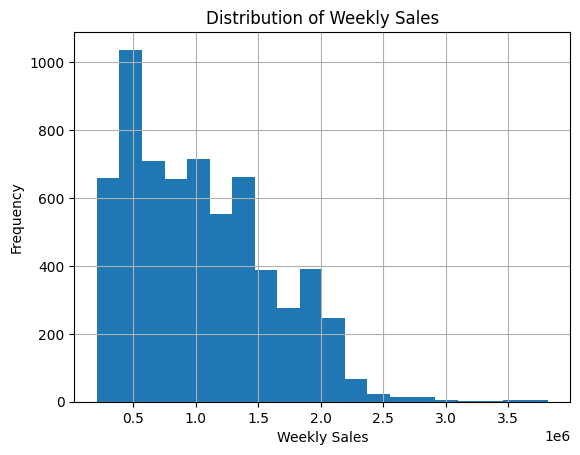

In [33]:
import matplotlib.pyplot as plt  # Library used to create plots

# Create a histogram of the Weekly_Sales column
# We use 20 bins to make the distribution easier to read for presentation
df["Weekly_Sales"].hist(bins=20)

# Add a title to describe what the chart shows
plt.title("Distribution of Weekly Sales")

# Label the x-axis (sales values)
plt.xlabel("Weekly Sales")

# Label the y-axis (number of occurrences)
plt.ylabel("Frequency")

# Display the plot
plt.show()

# Distribution of Weekly Sales:

- The histogram shows a right-skewed distribution.

- Most weeks have sales below approx 2M, but a few weeks reach very high values (approx 3.8M), indicating outliers.

# SECTION 7 : Time Series Visualization
Plotting the weekly sales series helps visually inspect trend, noise, and possible structural breaks

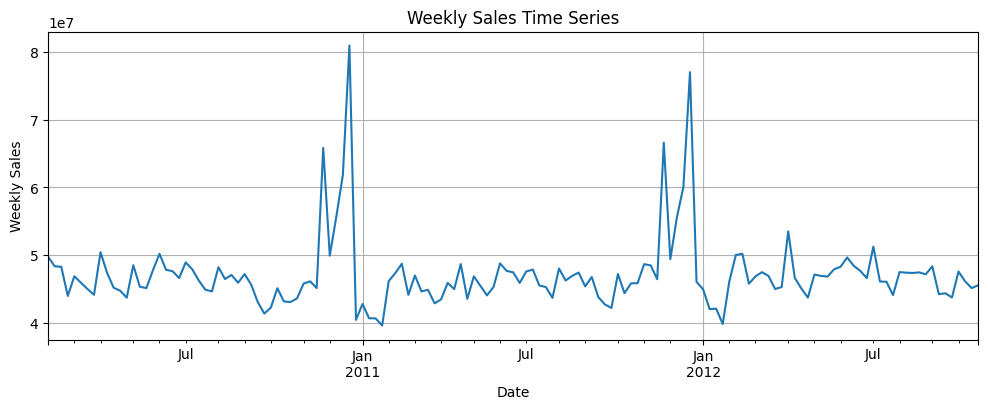

In [34]:
# Plot the Weekly_Sales time series
# figsize controls the size of the figure (width, height)
# title adds a title to the chart
weekly['Weekly_Sales'].plot(figsize=(12,4), title="Weekly Sales Time Series")

# Label the y-axis to indicate what the values represent
plt.ylabel("Weekly Sales")

# Add grid lines to improve readability of the time series
plt.grid()

# Display the plot
plt.show()

# Weekly Sales Time Series Analysis

# Key Observations:
- Strong Annual Seasonality:Clear spikes in January each year (likely due to holidays/sales events), reaching 70-80 million vs. a baseline of 40-50 million.
- Non-Stationarity: Sharp peaks and drops suggest the series is non-stationary, requiring differencing or log transformation.
-Increased Volatility in 2012:Higher fluctuations may indicate market or strategy changes.

#Modeling Implications:
- Use SARIMA (with seasonal parameters) to capture annual patterns.
- Consider log transformation to stabilize variance.
- Baseline: A "Seasonal Naive" model (using sales from the same week last year) could serve as a strong benchmark.

# Next Steps:
- Confirm non-stationarity with an ADF test.
- Decompose the series to isolate trend, seasonality, and residuals.



# Step 3.7 — Final Check

In [35]:
print("=== After Cleaning ===")
print(f"Rows:    {df_clean.shape[0]}  (started with {df.shape[0]})")
print(f"Missing: {df_clean.isnull().sum().sum()}")
print(f"Dupes:   {df_clean.duplicated().sum()}")

=== After Cleaning ===
Rows:    6435  (started with 6435)
Missing: 0
Dupes:   0


# Challenge
Write a reusable cleaning function that accepts any DataFrame and returns a clean version:


In [36]:
def clean_dataframe(raw_df, target_col, numeric_cols, categorical_cols):
    """
    Apply standard cleaning steps to a DataFrame.

    Parameters
    ----------
    raw_df           : pd.DataFrame  — the raw input
    target_col       : str           — column to predict (drop if missing)
    numeric_cols     : list[str]     — fill missing with median
    categorical_cols : list[str]     — fill missing with mode, standardise case

    Returns
    -------
    pd.DataFrame — cleaned copy
    """
    df = raw_df.copy()
    
    # Remove duplicates
    df = df.drop_duplicates()
    
    # Drop rows where target is missing
    df = df.dropna(subset=[target_col])
    
    # Fill missing numerical columns with median
    for col in numeric_cols:
        df[col] = df[col].fillna(df[col].median())
    
    # Fill missing categorical columns with mode and standardise case
    for col in categorical_cols:
        df[col] = df[col].fillna(df[col].mode()[0])
        df[col] = df[col].str.lower().str.strip()
    
    return df

# Test the function
df_test = clean_dataframe(
    df.reset_index(),
    target_col="Weekly_Sales",
    numeric_cols=["Temperature", "Fuel_Price", 
                  "CPI(customer price index)", "Unemployment"],
    categorical_cols=[]
)
print(f"Clean DataFrame shape: {df_test.shape}")
print(f"Missing values: {df_test.isnull().sum().sum()}")

Clean DataFrame shape: (6435, 8)
Missing values: 0


# STATISTICAL DIAGNOSTICS (HYPOTHESIS TESTING)

Most classical time series models assume that the data is stationary, meaning that their mean and variance do not change over time. The ADF test allows us to verify the presence of a unit root (non-stationarity).
- H₀ (Null Hypothesis): The series is non-stationary (presence of a unit root).

- H₁ (Alternative Hypothesis): The series is stationary

In [37]:

from statsmodels.tsa.stattools import adfuller  # Import ADF test for stationarity

# Run the Augmented Dickey-Fuller test on weekly sales
adf_result = adfuller(weekly["Weekly_Sales"], autolag='AIC')  # Use AIC to determine lag length

print("ADF Statistic:", round(adf_result[0], 4))  # Print ADF test statistic
print("p-value:", round(adf_result[1], 4))  # Print p-value
print("Critical Values:")  # Print critical values for comparison
for key, value in adf_result[4].items():
    print("  ", key, ":", round(value, 4))  # Print each critical value



ADF Statistic: -5.9083
p-value: 0.0
Critical Values:
   1% : -3.4786
   5% : -2.8827
   10% : -2.5781


The ADF test shows a statistic of -5.9083 with a p-value of 0.0, well below 0.05. Since the statistic is also lower than all critical values, we reject the null hypothesis. This indicates that the weekly sales series is stationary

# Seasonality Analysis — Autocorrelation Function (ACF)

- The ACF measures the correlation between an observation and its lagged
- versions over time. Visualizing the ACF helps identify repeating patterns
- that suggest seasonality.

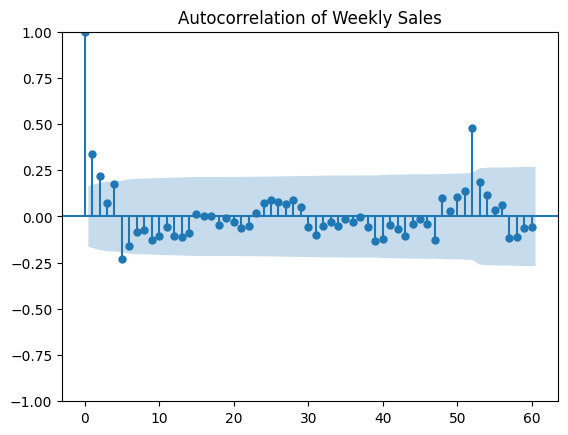

In [38]:
from statsmodels.graphics.tsaplots import plot_acf
# Visualize lags over more than one year (60 weeks) to detect annual seasonality
plot_acf(weekly["Weekly_Sales"], lags=60)
plt.title("Autocorrelation of Weekly Sales")
plt.show()

The ACF plot shows a strong correlation at lag 0 (as expected) and smaller spikes at certain lags, including around 52 weeks. This suggests a yearly seasonality in the weekly sales data, as correlations repeat roughly every 52 weeks. Most other lags fall within the confidence bounds, indicating limited autocorrelation outside the seasonal pattern

#Autocorrelation Significance : Ljung-Box Test
- While the ACF is visual, the Ljung-Box test mathematically determines
- whether the observed autocorrelations are statistically significant or
-simply white noise (random movements with no predictable signal).
#
- H0 (Null Hypothesis)       : The data are independently distributed
(no autocorrelation, white noise).
- H1 (Alternative Hypothesis): The data exhibit a temporal dependence

structure (significant autocorrelation).

In [39]:
from statsmodels.stats.diagnostic import acorr_ljungbox
# Ljung-Box test on the first 16 lags
lb_test = acorr_ljungbox(weekly["Weekly_Sales"], lags=[16], return_df=True)
print(lb_test)

      lb_stat  lb_pvalue
16  52.819063   0.000008


#Interpretation:
The data exhibits significant autocorrelation, so (reject H₀).

# Stage 4 — Feature Engineering
Feature engineering creates new columns that help the model learn patterns it would otherwise miss. For weekly retail sales forecasting, a human expert would consider: past sales values (lags), recent trends (rolling averages), and calendar patterns (seasonality)

# Step 4.0 — Work on a copy


In [40]:
work = weekly[["Weekly_Sales"]].copy() 

# Step 4.1 — Lag Features (Date/time decomposition)

In [41]:
for k in (1, 2, 4, 8, 12, 26, 52):
    work[f"y_lag_{k}"] = work["Weekly_Sales"].shift(k)

# Step 4.2 — Rolling Statistics (Aggregation features)
Rolling mean and standard deviation capture recent trends and volatility. shift(1) ensures causality — no future data is used.

In [42]:
work["ma_4"]  = work["Weekly_Sales"].shift(1).rolling(4,  min_periods=2).mean()
work["ma_12"] = work["Weekly_Sales"].shift(1).rolling(12, min_periods=3).mean()
work["std_4"] = work["Weekly_Sales"].shift(1).rolling(4,  min_periods=2).std()

# Step 4.3 — Calendar Features (Ratio/decomposition)
Extract temporal metadata to capture seasonal patterns across weeks, months, and years.

In [43]:
iso = work.index.isocalendar()
work["weekofyear"] = iso.week.astype(int)
work["month"]      = work.index.month
work["year"]       = work.index.year

## Feature Engineering
Purpose
Create features to capture temporal dependence and seasonality.
Approach

Lag Features: Add shifted values (y_lag_1, y_lag_52) to capture autocorrelation.

Example: y_lag_1 = sales from the previous week.

Rolling Statistics: Compute rolling means (ma_4, ma_12) to smooth fluctuations.

Example: ma_4 = mean of the last 4 weeks.

Calendar Features: Extract weekofyear, month, year to capture annual seasonality


In [44]:

# ── Step 4.1 — Lag Features 
for k in (1, 2, 4, 8, 12, 26, 52):
    work[f"y_lag_{k}"] = work["Weekly_Sales"].shift(k)

# ── Step 4.2 — Rolling Statistics 
work["ma_4"]  = work["Weekly_Sales"].shift(1).rolling(4,  min_periods=2).mean()
work["ma_12"] = work["Weekly_Sales"].shift(1).rolling(12, min_periods=3).mean()
work["std_4"] = work["Weekly_Sales"].shift(1).rolling(4,  min_periods=2).std()

# ── Step 4.3 — Calendar Features 
iso = work.index.isocalendar()
work["weekofyear"] = iso.week.astype(int)
work["month"]      = work.index.month
work["year"]       = work.index.year

# ── Drop NaNs from lags/rolling 
before = len(work)
work = work.replace([np.inf, -np.inf], np.nan).dropna()
print(f"Rows removed by NaN/inf: {before - len(work)} → {len(work)} rows remain")

# ── Sanity check─
assert not np.isinf(work.values).any(), "inf detected in work!"
assert not np.isnan(work.values).any(), "NaN detected in work!"
print("Feature engineering done. No inf/NaN. Sample:")
print(work.head())

Rows removed by NaN/inf: 52 → 91 rows remain
Feature engineering done. No inf/NaN. Sample:
            Weekly_Sales      y_lag_1      y_lag_2      y_lag_4      y_lag_8  \
Date                                                                           
2011-02-04   46153111.12  39599852.99  40654648.03  42775787.77  55666770.39   
2011-02-11   47336192.79  46153111.12  39599852.99  40673678.04  61820799.85   
2011-02-18   48716164.12  47336192.79  46153111.12  40654648.03  80931415.60   
2011-02-25   44125859.84  48716164.12  47336192.79  39599852.99  40432519.00   
2011-03-04   46980603.74  44125859.84  48716164.12  46153111.12  42775787.77   

               y_lag_12     y_lag_26     y_lag_52          ma_4         ma_12  \
Date                                                                            
2011-02-04  46124800.83  48204999.12  49750740.50  4.092599e+07  5.079466e+07   
2011-02-11  45125584.18  46464418.41  48336677.63  4.177032e+07  5.079702e+07   
2011-02-18  65821003.24 

"""
### Feature Engineering Summary
#Lag Features: Added lags for 1, 2, 4, 8, 12, 26, and 52 weeks to capture:
- Short-term trends ("y_lag_1", "y_lag_2").
- Seasonal patterns ("y_lag_52` for annual seasonality).

# Rolling Features:
- "ma_4", "ma_12": Moving averages to smooth short-term volatility.
- "std_4": Rolling standard deviation to capture volatility.

# Calendar Features:
- "weekofyear", "month", "year": Temporal metadata for seasonality modeling.

- NaN rows dropped (due to lags/rolling windows).
- Ready for training time-series models (SARIMA and Random forest).



# Panel Features per Store
Generate store-level lag and rolling features, plus exogenous variables if available.

In [45]:
w = (df.reset_index()  # Reset index to make 'Date' a column for sorting
       .assign(Date=lambda x: pd.to_datetime(x['Date']))  # Ensure Date is datetime
       .sort_values(["Store","Date"])  # Sort by Store and Date
       .set_index("Date")  # Set 'Date' back as index for time-series operations
       .groupby("Store"))  # Group by Store for per-store processing

feat = []  # Initialize list to store feature-engineered DataFrames
for store, g in w:
    g = g.copy()  # Create a copy of the group to avoid SettingWithCopyWarning
    g.index = pd.to_datetime(g.index)  # Ensure DatetimeIndex for isocalendar()
    for k in (1,2,4,8,12,26,52):  # Create lag features for various time steps
        g[f"y_lag_{k}"] = g["Weekly_Sales"].shift(k)
    g["ma_4"]  = g["Weekly_Sales"].shift(1).rolling(4,  min_periods=2).mean()  # 4-week moving average
    g["ma_12"] = g["Weekly_Sales"].shift(1).rolling(12, min_periods=3).mean()  # 12-week moving average
    g["std_4"] = g["Weekly_Sales"].shift(1).rolling(4,  min_periods=2).std()  # 4-week rolling standard deviation
    # Calendar features
    iso = g.index.isocalendar()  # Extract ISO calendar info
    g["weekofyear"] = iso.week.astype(int)  # Week of the year
    g["month"]      = g.index.month  # Month
    g["year"]       = g.index.year  # Year
    g["Store"] = store  # Store identifier
    feat.append(g)  # Append feature-engineered DataFrame to list

# Concatenate all individual store feature dataframes into a single 'engineered' DataFrame
engineered = pd.concat(feat)

before = len(engineered)  # Count rows before dropping NA
engineered = engineered.dropna()  # Drop rows with NA values
print("Rows removed:", before - len(engineered))  # Print number of rows removed

Rows removed: 2340


2340 rows removed (expected due to lag/rolling window effects on each store's data)

# Step 4.4 — Encode Categorical Columns
Store is encoded via ColumnTransformer with OneHotEncoder. No pd.get_dummies needed here since encoding is handled in the pipeline.

In [46]:
cat_cols = ['Store']
num_cols = [c for c in engineered.drop(columns=['Weekly_Sales']).columns 
            if c not in cat_cols]

pre = ColumnTransformer([
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_cols),
    ('num', 'passthrough', num_cols)
])

print('Categorical columns:', cat_cols)
print('Numerical columns:', num_cols)

Categorical columns: ['Store']
Numerical columns: ['Holiday_Flag', 'Temperature', 'Fuel_Price', 'CPI(customer price index)', 'Unemployment', 'y_lag_1', 'y_lag_2', 'y_lag_4', 'y_lag_8', 'y_lag_12', 'y_lag_26', 'y_lag_52', 'ma_4', 'ma_12', 'std_4', 'weekofyear', 'month', 'year']


# Step 4.5 — Validate New Features
Check that no NaN values were introduced by the feature engineering steps.

In [47]:
for col in work.columns:
    n_missing = work[col].isnull().sum()
    if n_missing > 0:
        print(f'WARNING: {col} has {n_missing} missing values after engineering')

print('Feature validation complete.')
print(f'Final feature count: {work.shape[1]} columns')

Feature validation complete.
Final feature count: 14 columns


##  Challenge — Feature Importance Preview (Mutual Information)
We use Mutual Information instead of RandomForestClassifier since this is a regression problem.

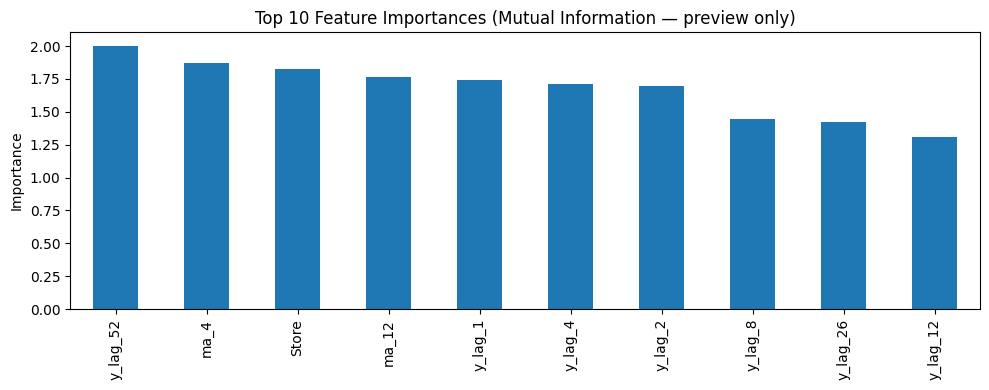

y_lag_52    2.004241
ma_4        1.874727
Store       1.828681
ma_12       1.766649
y_lag_1     1.742031
y_lag_4     1.712421
y_lag_2     1.693805
y_lag_8     1.445504
y_lag_26    1.423735
y_lag_12    1.311832
dtype: float64


In [48]:
cutoff_date = pd.Timestamp('2012-01-01')
df_train_mi = engineered[engineered.index < cutoff_date]

X_mi = df_train_mi.drop(columns=['Weekly_Sales'])
y_mi = df_train_mi['Weekly_Sales']

discrete_features_names = ['Store', 'Holiday_Flag', 'weekofyear', 'month', 'year']
discrete_features_indices = [idx for idx, col in enumerate(X_mi.columns) 
                              if col in discrete_features_names]

mi = mutual_info_regression(X_mi, y_mi, 
                             discrete_features=discrete_features_indices, 
                             random_state=42)
sel = pd.Series(mi, index=X_mi.columns).sort_values(ascending=False)

sel.head(10).plot(kind='bar', figsize=(10, 4))
plt.title('Top 10 Feature Importances (Mutual Information — preview only)')
plt.ylabel('Importance')
plt.tight_layout()
plt.show()

print(sel.head(10))


# •	Feature selection decisions
Main goal:
Reduce the number of variables (features) to improve model performance while avoiding overfitting, focusing on:

The most informative features for predicting weekly sales.
The interpretability of the model (understanding which variables actually influence sales).

In [49]:
from sklearn.feature_selection import mutual_info_regression  # Import mutual info for feature selection

cutoff_date = pd.Timestamp("2012-01-01")  # Define cutoff date for training data
df_train_mi = engineered[engineered.index < cutoff_date]  # Filter data before cutoff date

X_mi = df_train_mi.drop(columns=["Weekly_Sales"])  # Features: all columns except Weekly_Sales
y_mi = df_train_mi["Weekly_Sales"]  # Target: Weekly_Sales

discrete_features_names = ["Store", "Holiday_Flag", "weekofyear", "month", "year"]  # List of discrete features
discrete_features_indices = [idx for idx, col in enumerate(X_mi.columns) if col in discrete_features_names]  # Get indices of discrete features

mi = mutual_info_regression(X_mi, y_mi, discrete_features=discrete_features_indices, random_state=42)  # Calculate mutual information
sel = pd.Series(mi, index=X_mi.columns).sort_values(ascending=False)  # Convert to Series and sort by importance
sel.head(20)  # Display top 20 most important features


y_lag_52                     2.004241
ma_4                         1.874727
Store                        1.828681
ma_12                        1.766649
y_lag_1                      1.742031
y_lag_4                      1.712421
y_lag_2                      1.693805
y_lag_8                      1.445504
y_lag_26                     1.423735
y_lag_12                     1.311832
Unemployment                 0.926042
CPI(customer price index)    0.603437
std_4                        0.380584
Temperature                  0.100630
Fuel_Price                   0.011748
Holiday_Flag                 0.006830
weekofyear                   0.000000
month                        0.000000
year                         0.000000
dtype: float64

#Final feature set
#Top Predictors:
- "y_lag_52" (2.004): Strongest feature, confirming annual seasonality (e.g., holiday spikes).
- "ma_4" (1.875): Short-term moving average smooths noise, capturing recent trends.
- "Store" (1.829): Store-specific effects significantly impact sales.
- "ma_12" (1.767): Medium-term trends (e.g., quarterly patterns).
- "y_lag_1" (1.742): Immediate past sales strongly influence next week.

#Moderate Impact:
- Lags: "y_lag_4", "y_lag_2", "y_lag_8", "y_lag_26", "y_lag_12" (capture multi-week dependencies).
- "Unemployment" (0.926): Economic factor with some predictive power.

#Low/No Impact:
- "CPI", "std_4", "Temperature", "Fuel_Price", "Holiday_Flag": Weak or negligible influence.
- Calendar features ("weekofyear", "month", "year"): Redundant (likely already captured by lags).

#Action:
- Prioritize top 5-10 features for modeling (e.g., "y_lag_52", "ma_4", "Store").
- Drop zero-impact features ("weekofyear", "month", "year") to simplify the model.



# Stage 5 — Split Your Data
This is a time series problem. A random split would cause data leakage — future data would appear in the training set. A strict chronological split is mandatory.


## Step 5.1 — Define Features and Target

In [50]:
TARGET_COL = "Weekly_Sales"
X_full = work.drop(columns=[TARGET_COL])
y      = work[TARGET_COL]

# Step 5.2 — Time-Based Split (cutoff: 2012-01-01)
We use Option B — time-based split. All observations before January 1, 2012 are used for training. Observations from January 1, 2012 onwards are reserved for testing.

In [51]:
cutoff  = pd.Timestamp("2012-01-01")
X_train = X_full[X_full.index < cutoff]
X_test  = X_full[X_full.index >= cutoff]
y_train = y[y.index < cutoff]
y_test  = y[y.index >= cutoff]

print(f"Train: {X_train.shape[0]} rows | Test: {X_test.shape[0]} rows")

Train: 48 rows | Test: 43 rows


# Step 5.3 — Feature Standardization
The scaler is fitted on training data only — never on test data. This prevents data leakage.

In [52]:
from sklearn.preprocessing import StandardScaler

scaler    = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)
# Final verification
assert not np.isinf(X_train_s).any(), "inf in X_train_s!"
assert not np.isinf(X_test_s).any(),  "inf in X_test_s!"
print("Scaling done. No inf detected.")
print("X_train:", X_train_s.shape, "| X_test:", X_test_s.shape)

Scaling done. No inf detected.
X_train: (48, 13) | X_test: (43, 13)


# Step 5.4 — Save Splits

# Summary
# Dataset Shapes:
- Training Set (X_train): 48 samples, 14 features
- Test Set (X_test): 43 samples, 14 features

# Observations:
To prevent data leakage, the dataset was split chronologically using a fixed cutoff date.

All observations before January 1, 2012 were used for training, while observations on or after this date were reserved for testing.

This time-based split ensures that the model is trained only on past data and evaluated on future data, which reflects a realistic forecasting scenario.

Importantly, feature standardization was performed by fitting the scaler exclusively on the training data and then applying the transformation to the test set. This guarantees that no information from the test set influenced the training process.

In [ ]:
# Save the training features to a CSV file (step for future use or reproducibility)
X_train.to_csv("../data/processed/X_train.csv", index=False)

# Save the test features to a CSV file
X_test.to_csv("../data/processed/X_test.csv", index=False)

# Save the training target variable (sales) to a CSV file
y_train.to_csv("../data/processed/y_train.csv", index=False)

# Save the test target variable (sales) to a CSV file
y_test.to_csv("../data/processed/y_test.csv", index=False)
print("Splits saved.")

Splits saved.


: 